## Introduction to Probability and Statistics
## Assignment

In this assignment, we will use the dataset of diabetes patients taken [from here](https://www4.stat.ncsu.edu/~boos/var.select/diabetes.html).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
url = "https://raw.githubusercontent.com/saisanjaypotluri/Data-Science-For-Beginners/main/data/diabetes.tsv"

df = pd.read_csv(
    url,
    sep="\t"
    )

df.head()

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
0,59,2,32.1,101.0,157,93.2,38.0,4.0,4.8598,87,151
1,48,1,21.6,87.0,183,103.2,70.0,3.0,3.8918,69,75
2,72,2,30.5,93.0,156,93.6,41.0,4.0,4.6728,85,141
3,24,1,25.3,84.0,198,131.4,40.0,5.0,4.8903,89,206
4,50,1,23.0,101.0,192,125.4,52.0,4.0,4.2905,80,135



In this dataset, columns as the following:
* Age and sex are self-explanatory
* BMI is body mass index
* BP is average blood pressure
* S1 through S6 are different blood measurements
* Y is the qualitative measure of disease progression over one year

Let's study this dataset using methods of probability and statistics.

### Task 1: Compute mean values and variance for all values

In [4]:
column_means = df.mean(numeric_only=True)
print(column_means)
var = df.var()
print(var)

AGE     48.518100
SEX      1.468326
BMI     26.375792
BP      94.647014
S1     189.140271
S2     115.439140
S3      49.788462
S4       4.070249
S5       4.641411
S6      91.260181
Y      152.133484
dtype: float64
AGE     171.846610
SEX       0.249561
BMI      19.519798
BP      191.304401
S1     1197.717241
S2      924.955494
S3      167.293585
S4        1.665261
S5        0.272892
S6      132.165712
Y      5943.331348
dtype: float64


### Task 2: Plot boxplots for BMI, BP and Y depending on gender

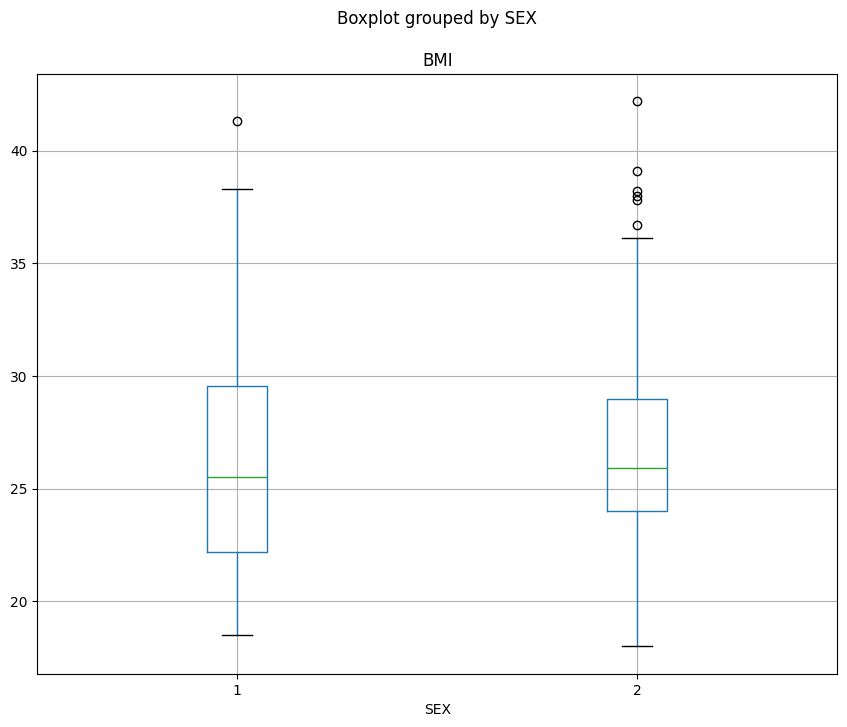

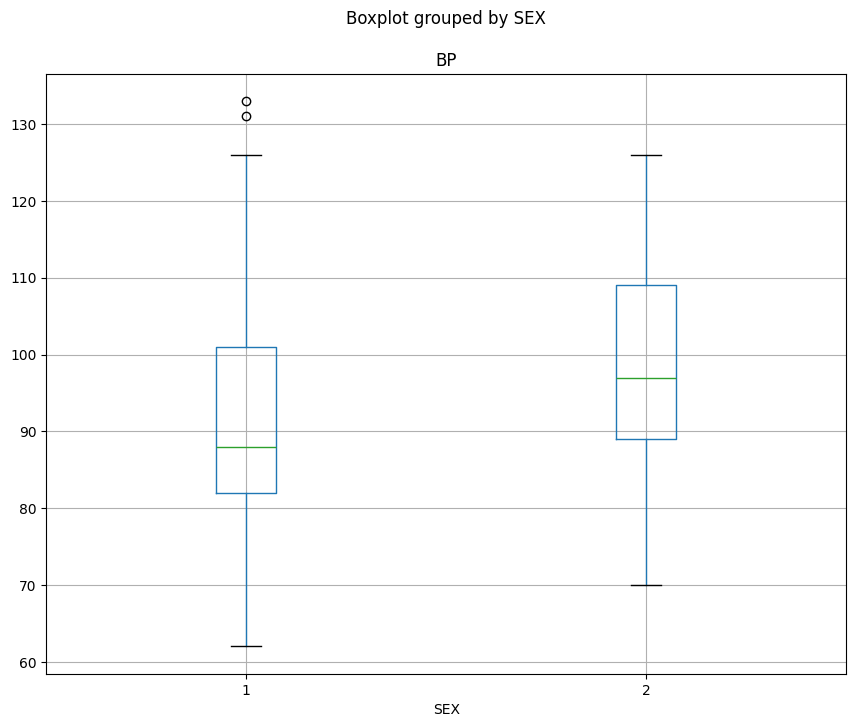

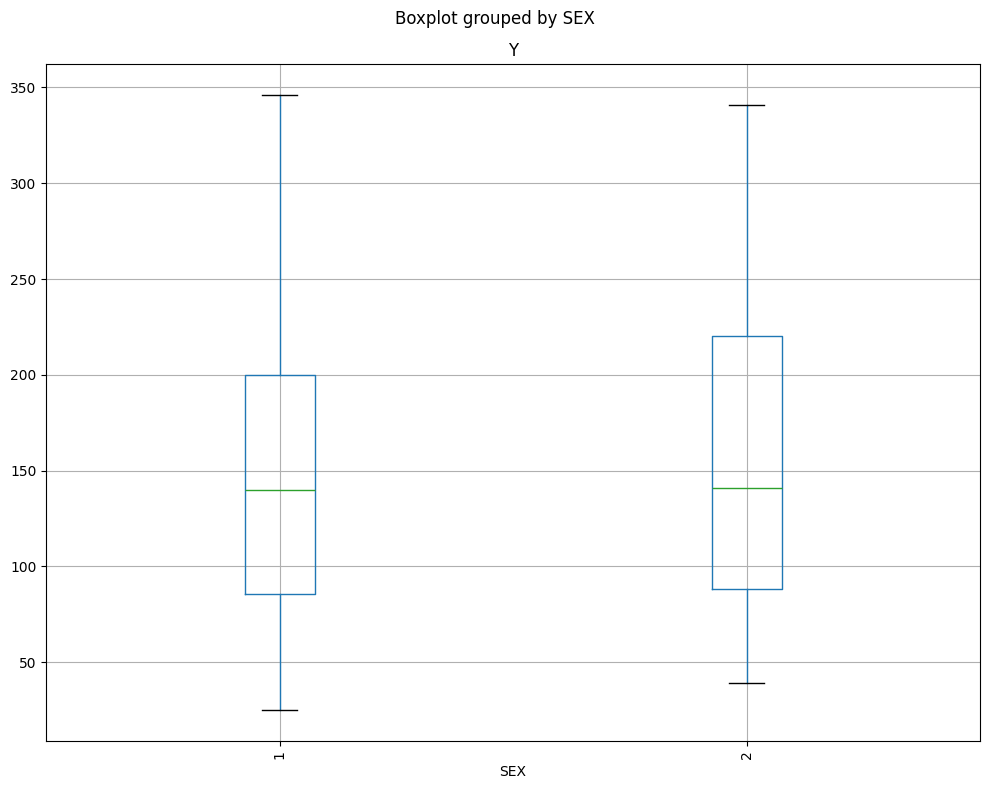

In [5]:
df.boxplot(column='BMI', by='SEX', figsize=(10,8))
df.boxplot(column='BP', by='SEX', figsize=(10,8))
df.boxplot(column='Y', by='SEX', figsize=(10,8))
plt.xticks(rotation='vertical')
plt.tight_layout()
plt.show()

### Task 3: What is the the distribution of Age, Sex, BMI and Y variables?

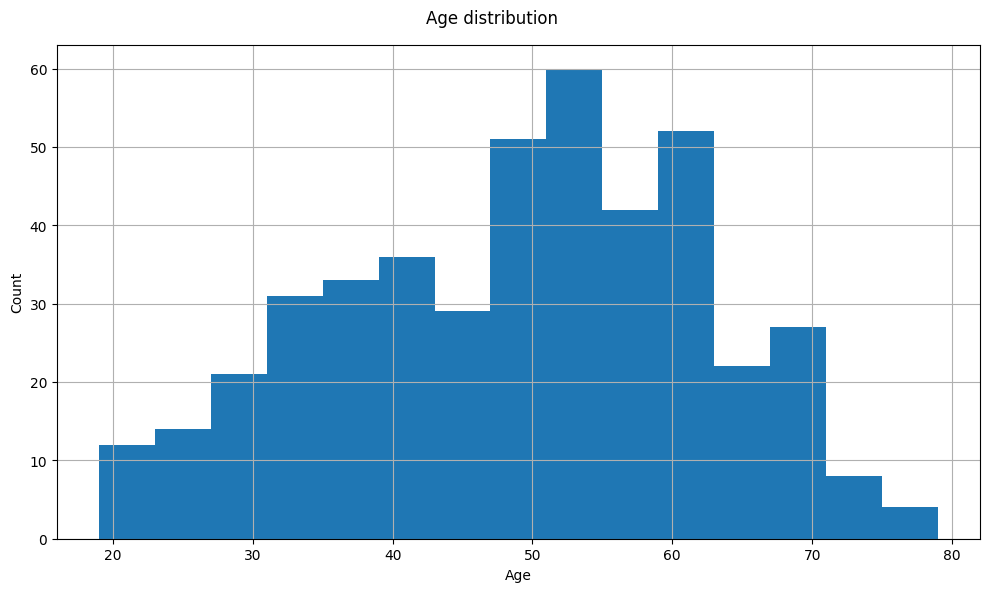

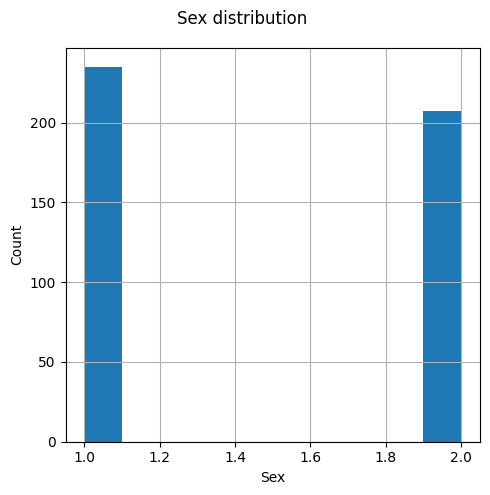

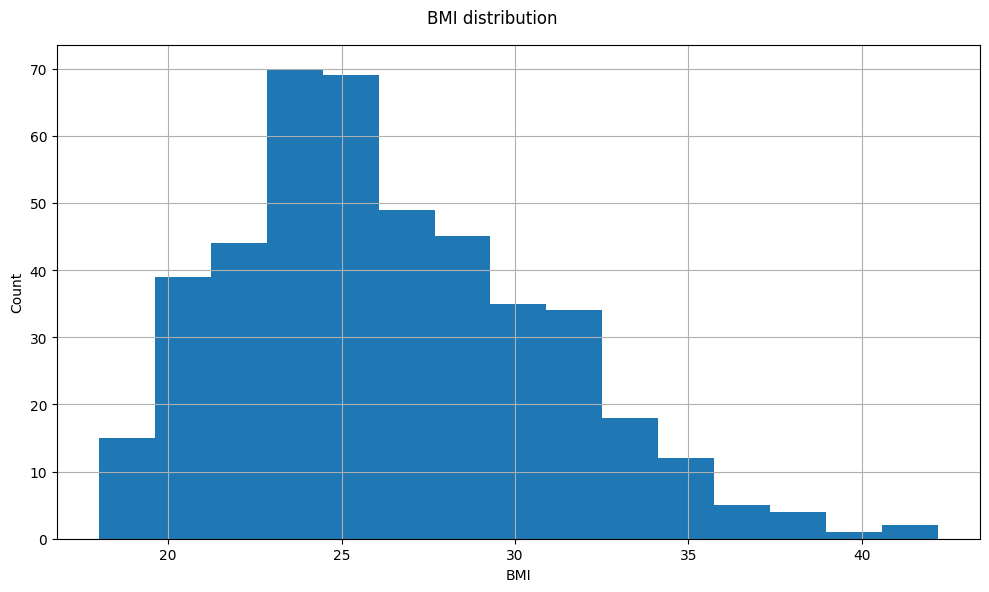

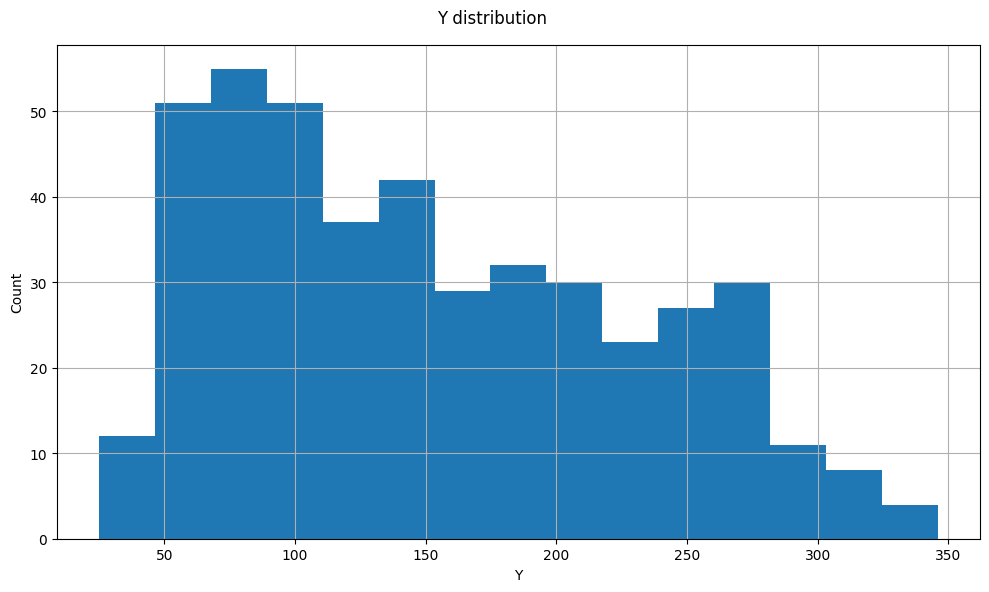

In [6]:
df['AGE'].hist(bins=15, figsize=(10,6))
plt.suptitle('Age distribution ')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

df['SEX'].hist(bins=10, figsize=(5,5))
plt.suptitle('Sex distribution ')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

df['BMI'].hist(bins=15, figsize=(10,6))
plt.suptitle('BMI distribution ')
plt.xlabel('BMI')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

df['Y'].hist(bins=15, figsize=(10,6))
plt.suptitle('Y distribution ')
plt.xlabel('Y')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Task 4: Test the correlation between different variables and disease progression (Y)

> **Hint** Correlation matrix would give you the most useful information on which values are dependent.

In [10]:
AGE = df['AGE']
SEX = df['SEX']
BMI = df['BMI']
BP = df['BP']
S1 = df['S1']
S2 = df['S2']
S3 = df['S3']
S4 = df['S4']
S5 = df['S5']
S6 = df['S6']
Y = df['Y']

In [21]:
variables = {
    "AGE": AGE,
    "SEX": SEX,
    "BMI": BMI,
    "BP": BP,
    "S1": S1,
    "S2": S2,
    "S3": S3,
    "S4": S4,
    "S5": S5,
    "S6": S6
}

for name, var in variables.items():
    cov_matrix = np.cov(var, Y)
    corr = np.corrcoef(var, Y)[0, 1]

    print(f"{name}")
    print(f"Covariance matrix:\n{cov_matrix}")
    print(f"Covariance = {cov_matrix[0, 1]}")
    print(f"Correlation = {corr}\n")
    
    


AGE
Covariance matrix:
[[ 171.84661044  189.88306605]
 [ 189.88306605 5943.33134792]]
Covariance = 189.8830660469315
Correlation = 0.1878887507189197

SEX
Covariance matrix:
[[2.49561363e-01 1.65843260e+00]
 [1.65843260e+00 5.94333135e+03]]
Covariance = 1.658432603810755
Correlation = 0.04306199845160536

BMI
Covariance matrix:
[[  19.51979812  199.74859021]
 [ 199.74859021 5943.33134792]]
Covariance = 199.74859020531292
Correlation = 0.5864501344746887

BP
Covariance matrix:
[[ 191.30440104  470.749878  ]
 [ 470.749878   5943.33134792]]
Covariance = 470.749878002483
Correlation = 0.44148175856257094

S1
Covariance matrix:
[[1197.71724074  565.68418136]
 [ 565.68418136 5943.33134792]]
Covariance = 565.6841813648534
Correlation = 0.21202248101455065

S2
Covariance matrix:
[[ 924.95549404  408.09226922]
 [ 408.09226922 5943.33134792]]
Covariance = 408.0922692153785
Correlation = 0.1740535869687426

S3
Covariance matrix:
[[ 167.29358538 -393.65877377]
 [-393.65877377 5943.33134792]]
Covar

### Task 5: Test the hypothesis that the degree of diabetes progression is different between men and women

In [23]:
from scipy.stats import ttest_ind

# Convert to numeric if necessary
df['Y'] = pd.to_numeric(df['Y'], errors='coerce')
df['SEX'] = pd.to_numeric(df['SEX'], errors='coerce')

# Remove missing values
men = df.loc[df['SEX'] == 1, 'Y'].dropna()
women = df.loc[df['SEX'] == 2, 'Y'].dropna()

print("Men:", len(men))
print("Women:", len(women))

t_stat, p_value = ttest_ind(men, women, equal_var=False)

print(f"T-statistic = {t_stat:.3f}")
print(f"P-value = {p_value:.4f}")


Men: 235
Women: 207
T-statistic = -0.902
P-value = 0.3674
